# Build the surface ESP-Gaussian cache

Reconstruct $\zeta=w\exp(-\rho^2/R_c^2)$, compare it with uniform controls, and save one reusable table. Run this notebook first on Katana.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

HERE = Path.cwd().resolve()
ANALYSIS_ROOT = next((p for p in (HERE, *HERE.parents) if (p / "seacofs_tilt_tools.py").exists()), None)
if ANALYSIS_ROOT is None:
    raise FileNotFoundError("Run inside seacofs_eddy_tilt_analysis or one of its subfolders")
for path in (ANALYSIS_ROOT, HERE):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))
import seacofs_tilt_tools as tilt
import esp_pv_tools as ept
sns.set_theme(style="whitegrid", context="notebook")
palette = {"AE":"#c44e52", "CE":"#4c72b0"}


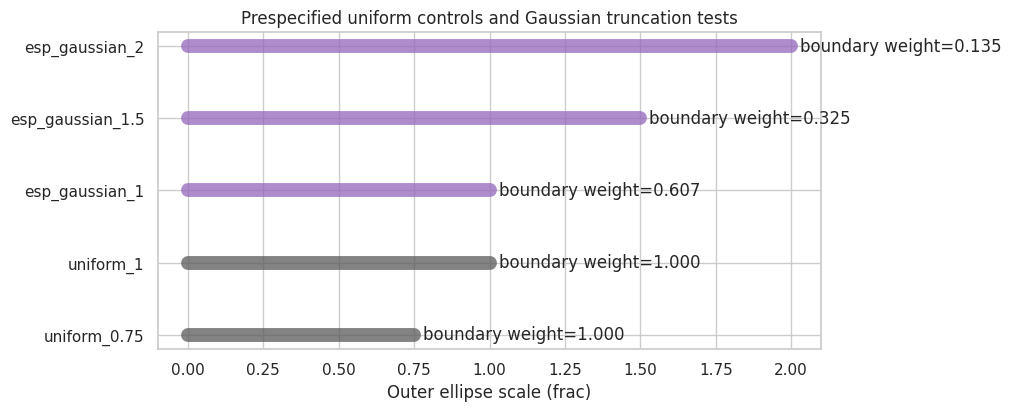

In [2]:
paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
eddies, _ = tilt.load_tilt_tables(paths)
specs = ept.method_specs()

fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
for y, row in specs.reset_index().iterrows():
    boundary_weight = np.exp(-0.5 * row.frac**2) if row.surface_method == "esp_gaussian" else 1
    ax.plot([0, row.frac], [y, y], lw=10, alpha=.75,
            color="tab:purple" if row.surface_method == "esp_gaussian" else "0.35")
    ax.text(row.frac+.03, y, f"boundary weight={boundary_weight:.3f}", va="center")
ax.set(yticks=range(len(specs)), yticklabels=specs.method, xlabel="Outer ellipse scale (frac)",
       title="Prespecified uniform controls and Gaussian truncation tests")
plt.show()

In [3]:
data = ept.build_cache(eddies, grid, specs)
destination = ept.cache_path()
destination.parent.mkdir(parents=True, exist_ok=True)
data.to_parquet(destination, index=False)

[1/5] uniform_0.75
[2/5] uniform_1
[3/5] esp_gaussian_1
[4/5] esp_gaussian_1.5
[5/5] esp_gaussian_2


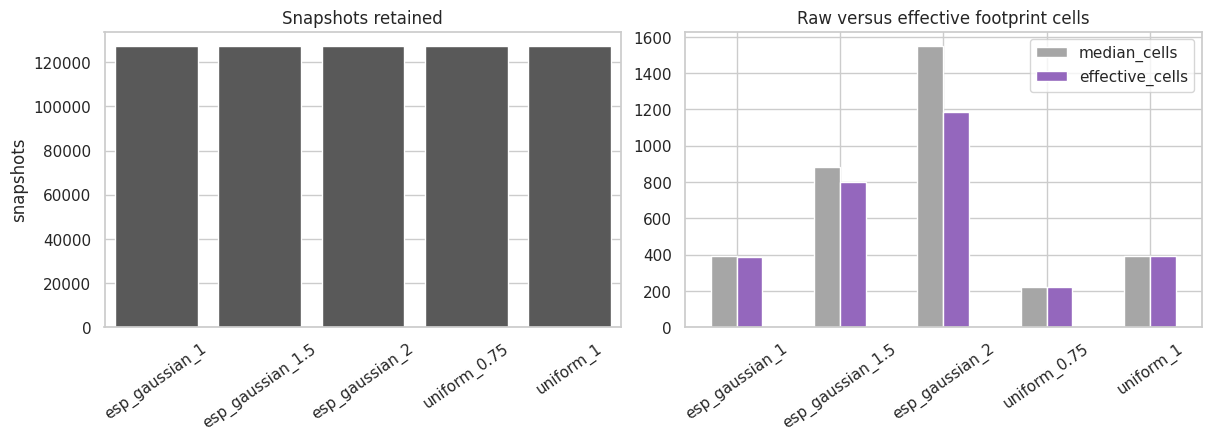

In [4]:
counts = data.groupby("method").agg(snapshots=("Day","size"), eddies=("Eddy","nunique"),
    median_cells=("PV_footprint_n","median"), effective_cells=("PV_weight_effective_n","median")).reset_index()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), constrained_layout=True)
sns.barplot(data=counts, x="method", y="snapshots", color=".35", ax=axes[0])
counts.plot(x="method", y=["median_cells","effective_cells"], kind="bar", ax=axes[1], color=[".65","tab:purple"])
for ax in axes: ax.tick_params(axis="x", rotation=35); ax.set_xlabel("")
axes[0].set_title("Snapshots retained"); axes[1].set_title("Raw versus effective footprint cells")
plt.show()